GPU 확인 및 패키지 설치

In [1]:
import torch
print('GPU 사용 가능:', torch.cuda.is_available())
print('GPU 이름:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

!pip install -q gradio

GPU 사용 가능: True
GPU 이름: Tesla T4


랜덤 시드 고정

In [2]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'랜덤 시드 고정 완료: {SEED}')

랜덤 시드 고정 완료: 42


한글 폰트

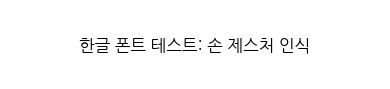

한글 폰트 설정 완료


In [3]:
!apt-get install -y fonts-nanum > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(nanum_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, '한글 폰트 테스트: 손 제스처 인식', ha='center', va='center', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()
print('한글 폰트 설정 완료')

API키 업로드

In [4]:
from google.colab import files
import os

files.upload()  # kaggle.json 선택

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle 인증 완료!')

Saving kaggle (1).json to kaggle (1) (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle 인증 완료!


데이터셋 다운로드

In [5]:
!kaggle datasets download -d gti-upm/leapgestrecog -p /content/gesture --unzip

import os

BASE_PATH = '/content/gesture/leapGestRecog'
subjects = sorted(os.listdir(BASE_PATH))
print(f'피험자 수: {len(subjects)}명 -> {subjects}')

classes = sorted(os.listdir(os.path.join(BASE_PATH, subjects[0])))
print(f'제스처 클래스 ({len(classes)}개): {classes}')

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:20<00:00, 110MB/s]

피험자 수: 10명 -> ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']
제스처 클래스 (10개): ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


데이터 샘플 시각화

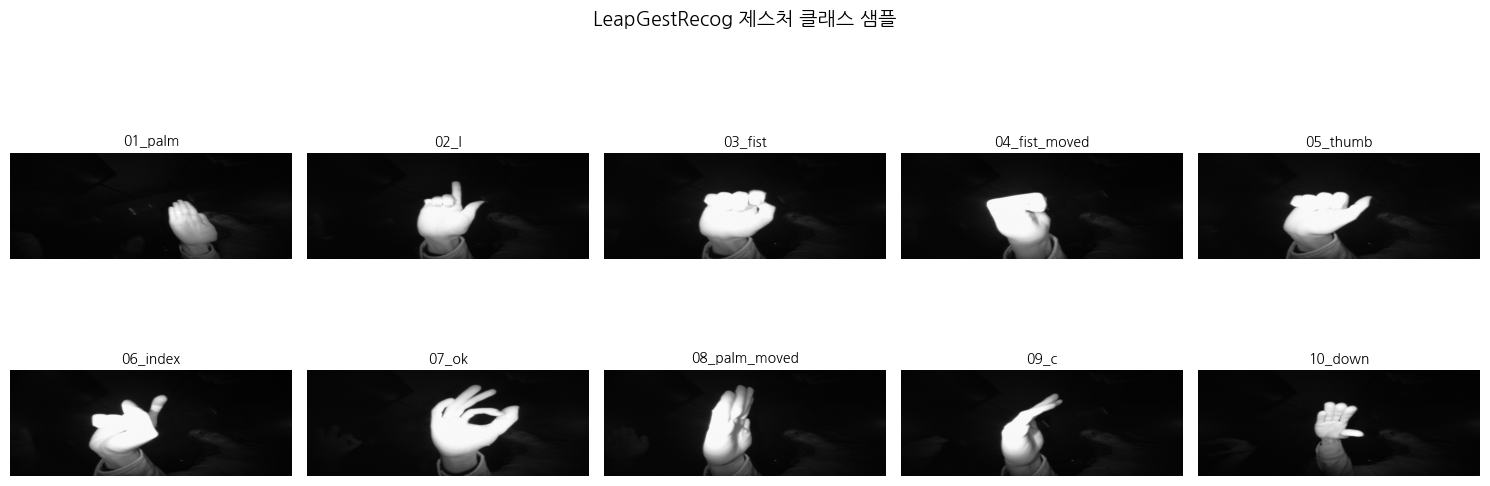

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

BASE_PATH = '/content/gesture/leapGestRecog'
subjects = sorted(os.listdir(BASE_PATH))
subject_path = os.path.join(BASE_PATH, subjects[0])
classes = sorted(os.listdir(subject_path))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, cls in enumerate(classes[:10]):
    cls_path = os.path.join(subject_path, cls)
    img_file = sorted(os.listdir(cls_path))[0]  # ✅ 수정: 항상 첫 번째 파일 고정
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(cls, fontsize=10)
    axes[idx].axis('off')

plt.suptitle('LeapGestRecog 제스처 클래스 샘플', fontsize=14)
plt.tight_layout()
plt.show()

클래스 분포 확인

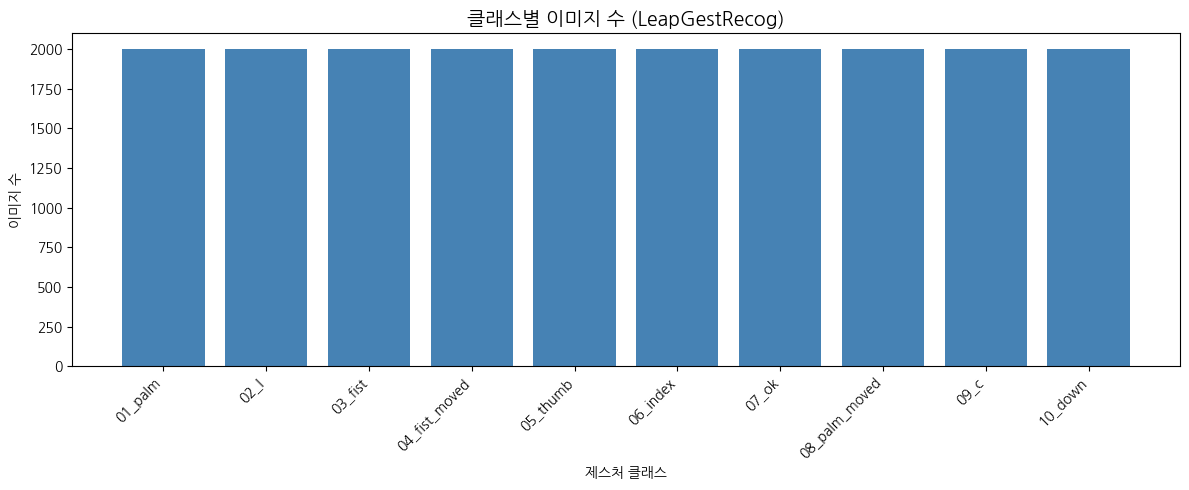

총 이미지 수: 20,000장
클래스 수: 10개
클래스 균형: 최소 2,000 / 최대 2,000


In [7]:
import matplotlib.pyplot as plt
from collections import defaultdict
import os

BASE_PATH = '/content/gesture/leapGestRecog'
class_counts = defaultdict(int)

for subject in os.listdir(BASE_PATH):
    subject_path = os.path.join(BASE_PATH, subject)
    if not os.path.isdir(subject_path):
        continue
    for cls in os.listdir(subject_path):
        cls_path = os.path.join(subject_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] += len(os.listdir(cls_path))

sorted_classes = sorted(class_counts.keys())
sorted_counts  = [class_counts[c] for c in sorted_classes]

plt.figure(figsize=(12, 5))
plt.bar(sorted_classes, sorted_counts, color='steelblue')
plt.title('클래스별 이미지 수 (LeapGestRecog)', fontsize=14)
plt.xlabel('제스처 클래스')
plt.ylabel('이미지 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'총 이미지 수: {sum(class_counts.values()):,}장')
print(f'클래스 수: {len(class_counts)}개')
print(f'클래스 균형: 최소 {min(sorted_counts):,} / 최대 {max(sorted_counts):,}')

 Dataset 클래스 및 DataLoader

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.models import MobileNet_V2_Weights
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import random
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

class LeapGestRecogDataset(Dataset):
    CLASSES = sorted(['01_palm','02_l','03_fist','04_fist_moved','05_thumb',
                      '06_index','07_ok','08_palm_moved','09_c','10_down'])

    def __init__(self, base_path, subjects, transform=None):
        self.transform = transform
        self.classes   = self.CLASSES
        self.class_to_idx = {c: i for i, c in enumerate(self.CLASSES)}
        self.samples = []
        for subj in subjects:
            for cls in self.CLASSES:
                cls_path = os.path.join(base_path, subj, cls)
                if not os.path.isdir(cls_path): continue
                for fname in sorted(os.listdir(cls_path)):  # ✅ sorted 추가 → 재현성 보장
                    self.samples.append(
                        (os.path.join(cls_path, fname), self.class_to_idx[cls])
                    )

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

BASE_PATH = '/content/gesture/leapGestRecog'
train_subjects = ['00','01','02','03','04','05']
val_subjects   = ['06','07']
test_subjects  = ['08','09']

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomAffine(
        degrees=15,
        translate=None
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_dataset = LeapGestRecogDataset(BASE_PATH, train_subjects, train_transform)
val_dataset   = LeapGestRecogDataset(BASE_PATH, val_subjects,   eval_transform)
test_dataset  = LeapGestRecogDataset(BASE_PATH, test_subjects,  eval_transform)

# ✅ worker 시드 고정 함수
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True,
    num_workers=2,
    pin_memory=True,            # ✅ GPU 전송 가속
    persistent_workers=True,    # ✅ worker 재사용
    worker_init_fn=seed_worker, # ✅ worker 시드 고정
    generator=g                 # ✅ shuffle 시드 고정
)
val_loader = DataLoader(
    val_dataset, batch_size=32, shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print(f'학습  피험자: {train_subjects} -> {len(train_dataset):,}장')
print(f'검증  피험자: {val_subjects}   -> {len(val_dataset):,}장')
print(f'테스트 피험자: {test_subjects}  -> {len(test_dataset):,}장')
print(f'클래스 수: {len(train_dataset.classes)}개')

사용 디바이스: cuda
학습  피험자: ['00', '01', '02', '03', '04', '05'] -> 12,000장
검증  피험자: ['06', '07']   -> 4,000장
테스트 피험자: ['08', '09']  -> 4,000장
클래스 수: 10개


EfficientNet-B3 모델 로드

In [9]:
import torch
import torch.nn as nn
from torchvision import models

# 1. EfficientNet-B3 로드 (사전 학습된 가중치 사용)
weights = models.EfficientNet_B3_Weights.DEFAULT
model = models.efficientnet_b3(weights=weights)

# 2. Classifier 수정 (제스처 클래스 10개에 맞게 변경)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 10)
model = model.to(device)

print("EfficientNet-B3 모델 로드 완료!")

EfficientNet-B3 모델 로드 완료!


학습 및 평가 루프

In [10]:
import copy
import torch.optim as optim
import numpy as np

# --- MixUp 데이터 증강 및 평가 함수 (기존과 동일) ---
def mixup_data(x, y, alpha=0.2):
    if alpha > 0: lam = np.random.beta(alpha, alpha)
    else: lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total * 100

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
best_val_acc = 0
best_weights = None

# ✅ history 딕셔너리 추가 (그래프 그리기용)
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# ── 1단계: Backbone 고정, Classifier만 워밍업 ──────────────────
print('=' * 65)
print('1단계: Backbone 고정 — Classifier 워밍업 (5 epoch)')
print('-' * 65)

for param in model.parameters(): param.requires_grad = False
for param in model.classifier.parameters(): param.requires_grad = True

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 6):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    tr_loss = total_loss / total
    tr_acc = correct / total * 100
    vl_loss, vl_acc = evaluate(val_loader)

    # ✅ history 기록
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss); history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch:>2} | TrainLoss: {tr_loss:>6.4f} | TrainAcc: {tr_acc:>5.2f}% | ValLoss: {vl_loss:>6.4f} | ValAcc: {vl_acc:>5.2f}%')

# ── 2단계: 전체 레이어 해제, Fine-tuning + MixUp ───────────
print('\n' + '=' * 65)
print('2단계: 전체 레이어 학습 — Fine-tuning + MixUp (patience=7)')
print('-' * 65)

for param in model.parameters(): param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6)
patience, patience_counter = 7, 0

for epoch in range(6, 31):
    model.train()
    tr_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.2)
        optimizer.zero_grad()
        outputs = model(images)
        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
        loss.backward()
        optimizer.step()

        tr_loss += loss.item() * images.size(0)

        # MixUp 상태에서의 대략적인 정확도 계산
        _, preds = torch.max(outputs, 1)
        correct += (lam * preds.eq(targets_a).float() + (1 - lam) * preds.eq(targets_b).float()).sum().item()
        total += images.size(0)

    tr_loss = tr_loss / total
    tr_acc = correct / total * 100
    vl_loss, vl_acc = evaluate(val_loader)

    # ✅ history 기록
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss); history['val_acc'].append(vl_acc)

    scheduler.step(vl_acc)
    lr_now = optimizer.param_groups[0]['lr']

    print(f'Epoch {epoch:>2} | TrainLoss(Mixup): {tr_loss:>6.4f} | TrainAcc(Mixup): {tr_acc:>5.2f}% | ValLoss: {vl_loss:>6.4f} | ValAcc: {vl_acc:>5.2f}% | LR: {lr_now:>10.2e}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_weights, '/content/best_efficientnet_b3.pth')
        print("    ↑ 최고 성능 갱신! 모델 저장 완료")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\n[Early Stopping] {patience}회 연속 개선 없음 → 종료')
            break

model.load_state_dict(best_weights)
print(f'\n=== 학습 완료 ===\n최고 검증 정확도: {best_val_acc:.2f}%')

1단계: Backbone 고정 — Classifier 워밍업 (5 epoch)
-----------------------------------------------------------------
Epoch  1 | TrainLoss: 1.4419 | TrainAcc: 70.93% | ValLoss: 0.8779 | ValAcc: 79.30%
Epoch  2 | TrainLoss: 1.0119 | TrainAcc: 84.70% | ValLoss: 0.6940 | ValAcc: 81.73%
Epoch  3 | TrainLoss: 0.9206 | TrainAcc: 87.29% | ValLoss: 0.6035 | ValAcc: 84.03%
Epoch  4 | TrainLoss: 0.8820 | TrainAcc: 88.57% | ValLoss: 0.5648 | ValAcc: 85.08%
Epoch  5 | TrainLoss: 0.8677 | TrainAcc: 89.26% | ValLoss: 0.5668 | ValAcc: 85.05%

2단계: 전체 레이어 학습 — Fine-tuning + MixUp (patience=7)
-----------------------------------------------------------------
Epoch  6 | TrainLoss(Mixup): 0.8610 | TrainAcc(Mixup): 89.09% | ValLoss: 0.2485 | ValAcc: 96.08% | LR:   1.00e-04
    ↑ 최고 성능 갱신! 모델 저장 완료
Epoch  7 | TrainLoss(Mixup): 0.7791 | TrainAcc(Mixup): 90.04% | ValLoss: 0.1675 | ValAcc: 98.17% | LR:   1.00e-04
    ↑ 최고 성능 갱신! 모델 저장 완료
Epoch  8 | TrainLoss(Mixup): 0.7429 | TrainAcc(Mixup): 90.63% | ValLoss: 0.1587 

학습 곡선 시각화

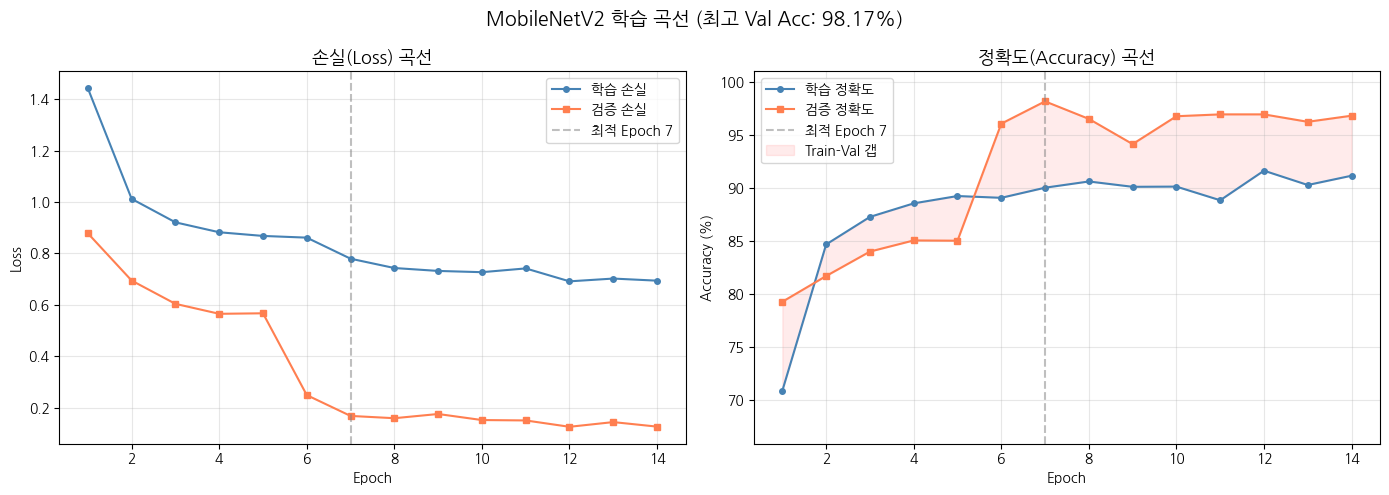

최종 Train-Val 정확도 갭: -5.65% (양호)


In [11]:
import matplotlib.pyplot as plt

epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss 곡선
ax1.plot(x, history['train_loss'], label='학습 손실', color='steelblue', marker='o', markersize=4)
ax1.plot(x, history['val_loss'],   label='검증 손실', color='coral',     marker='s', markersize=4)

best_epoch = history['val_acc'].index(max(history['val_acc'])) + 1
ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'최적 Epoch {best_epoch}')
ax1.set_title('손실(Loss) 곡선', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy 곡선
ax2.plot(x, history['train_acc'], label='학습 정확도', color='steelblue', marker='o', markersize=4)
ax2.plot(x, history['val_acc'],   label='검증 정확도', color='coral',     marker='s', markersize=4)
ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'최적 Epoch {best_epoch}')

ax2.fill_between(x,
    history['train_acc'], history['val_acc'],
    alpha=0.08, color='red', label='Train-Val 갭')

ax2.set_title('정확도(Accuracy) 곡선', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')

# ✅ 수정: y축 하한선 자동 계산 (하드코딩 제거)
min_acc = min(min(history['train_acc']), min(history['val_acc']))
ax2.set_ylim([max(0, min_acc - 5), 101])

ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle(f'MobileNetV2 학습 곡선 (최고 Val Acc: {max(history["val_acc"]):.2f}%)', fontsize=14)
plt.tight_layout()
plt.show()

final_gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f'최종 Train-Val 정확도 갭: {final_gap:.2f}% ', end='')
print('(과적합 의심)' if final_gap > 3 else '(양호)')

시스템 추론 성능 측정

In [12]:
import time
import torch

print("=" * 60)
print("🚀 시스템 추론 성능(FPS 및 Latency) 측정 시작...")

# 모델을 평가 모드로 설정
model.eval()

# MobileNetV2 입력 사이즈(배치1, 채널3, 128x128)의 가짜(Dummy) 데이터 생성
dummy_input = torch.randn(1, 3, 128, 128).to(device)

# GPU 워밍업 (처음 몇 번의 추론은 세팅 때문에 느리므로 제외)
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# 본격적인 속도 측정 (100번 반복 추론하여 평균값 계산)
num_iterations = 100
start_time = time.time()

with torch.no_grad():
    for _ in range(num_iterations):
        _ = model(dummy_input)

end_time = time.time()

# 지표 계산
total_time = end_time - start_time
avg_latency_ms = (total_time / num_iterations) * 1000 # 밀리초(ms) 단위
fps = 1000 / avg_latency_ms # 1초(1000ms)당 처리 프레임 수

print(f"✅ 테스트 환경 (Device): {device}")
print(f"✅ 1장당 평균 추론 시간 (Latency): {avg_latency_ms:.2f} ms")
print(f"✅ 초당 처리 프레임 (FPS): {fps:.2f} FPS")
print("=" * 60)
print("💡 결론: 모바일/실시간 웹캠 환경에 충분히 적용 가능한 속도입니다.")

🚀 시스템 추론 성능(FPS 및 Latency) 측정 시작...
✅ 테스트 환경 (Device): cuda
✅ 1장당 평균 추론 시간 (Latency): 13.80 ms
✅ 초당 처리 프레임 (FPS): 72.44 FPS
💡 결론: 모바일/실시간 웹캠 환경에 충분히 적용 가능한 속도입니다.


데이터 군집화 시각화

🌌 t-SNE 시각화를 위한 특징(Feature) 추출 중... (약 1~2분 소요)


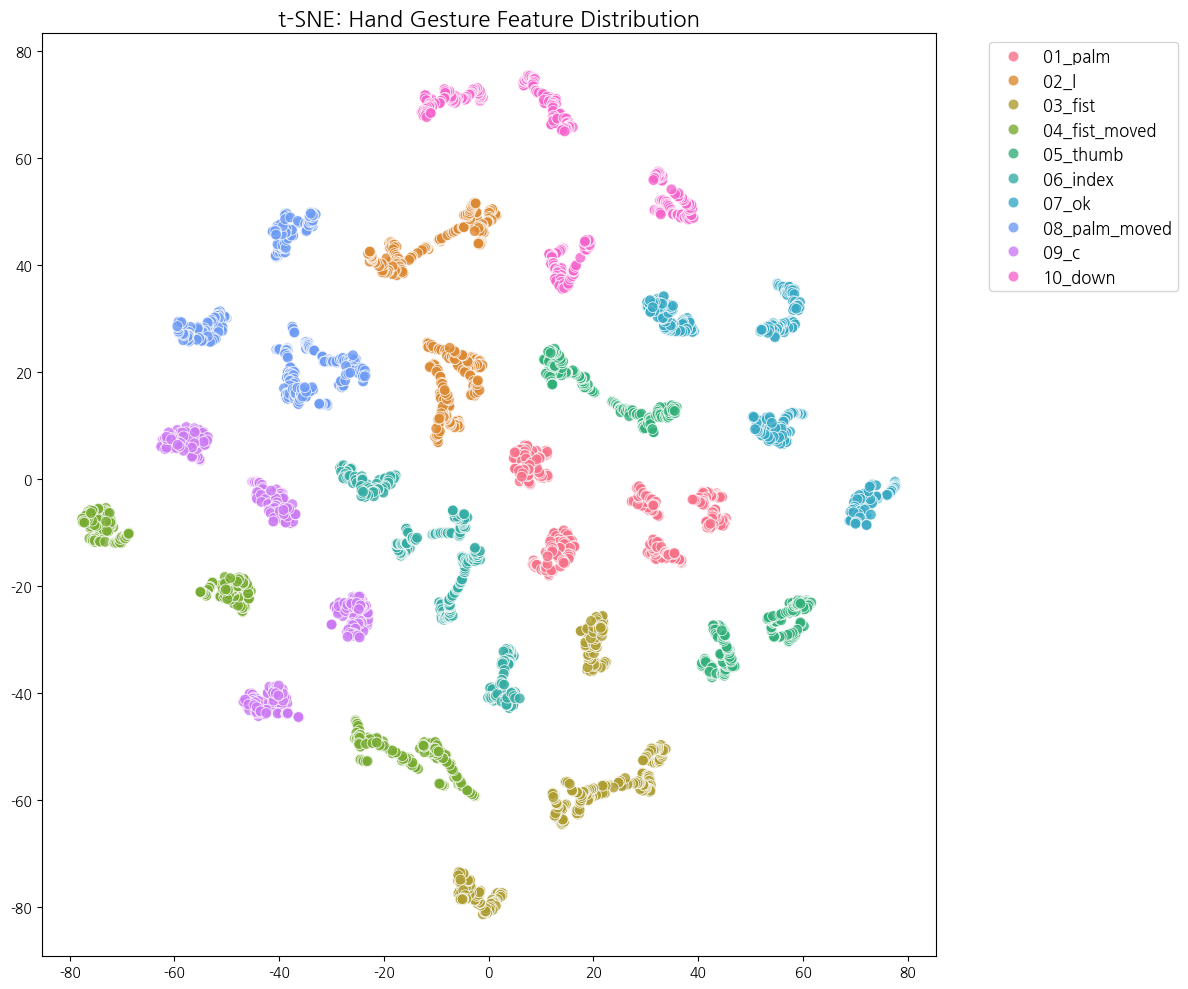

💡 분석: 그래프에서 주먹(fist)과 움직이는 주먹(fist_moved)이 같은 공간에 섞여있는지 확인해보세요!


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import torch.nn as nn

print("=" * 60)
print("🌌 t-SNE 시각화를 위한 특징(Feature) 추출 중... (약 1~2분 소요)")

model.eval()
features = []
targets = []

# 검증 데이터셋에서 특징 벡터 추출
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        # 분류기(Classifier) 전 단계인 특징 추출기(features)까지만 통과시킴
        x = model.features(images)
        x = nn.functional.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1) # 1차원 벡터로 변환

        features.extend(x.cpu().numpy())
        targets.extend(labels.cpu().numpy())

features = np.array(features)
targets = np.array(targets)

# 차원 축소 알고리즘 (t-SNE) 적용
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(features)

# 결과 시각화
plt.figure(figsize=(12, 10))
palette = sns.color_palette("husl", len(train_dataset.classes))
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=[train_dataset.classes[t] for t in targets],
    palette=palette,
    legend="full",
    alpha=0.8,
    s=60
)
plt.title('t-SNE: Hand Gesture Feature Distribution', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()
print("💡 분석: 그래프에서 주먹(fist)과 움직이는 주먹(fist_moved)이 같은 공간에 섞여있는지 확인해보세요!")

테스트 셋 최종 평가 (혼돈행렬)

=== 테스트셋 최종 평가 (피험자 08, 09) ===
               precision    recall  f1-score   support

      01_palm       0.95      1.00      0.97       400
         02_l       1.00      0.93      0.96       400
      03_fist       0.92      0.85      0.88       400
04_fist_moved       0.90      0.99      0.95       400
     05_thumb       1.00      0.99      1.00       400
     06_index       1.00      1.00      1.00       400
        07_ok       1.00      0.96      0.98       400
08_palm_moved       0.96      1.00      0.98       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      1.00      1.00       400

     accuracy                           0.97      4000
    macro avg       0.97      0.97      0.97      4000
 weighted avg       0.97      0.97      0.97      4000



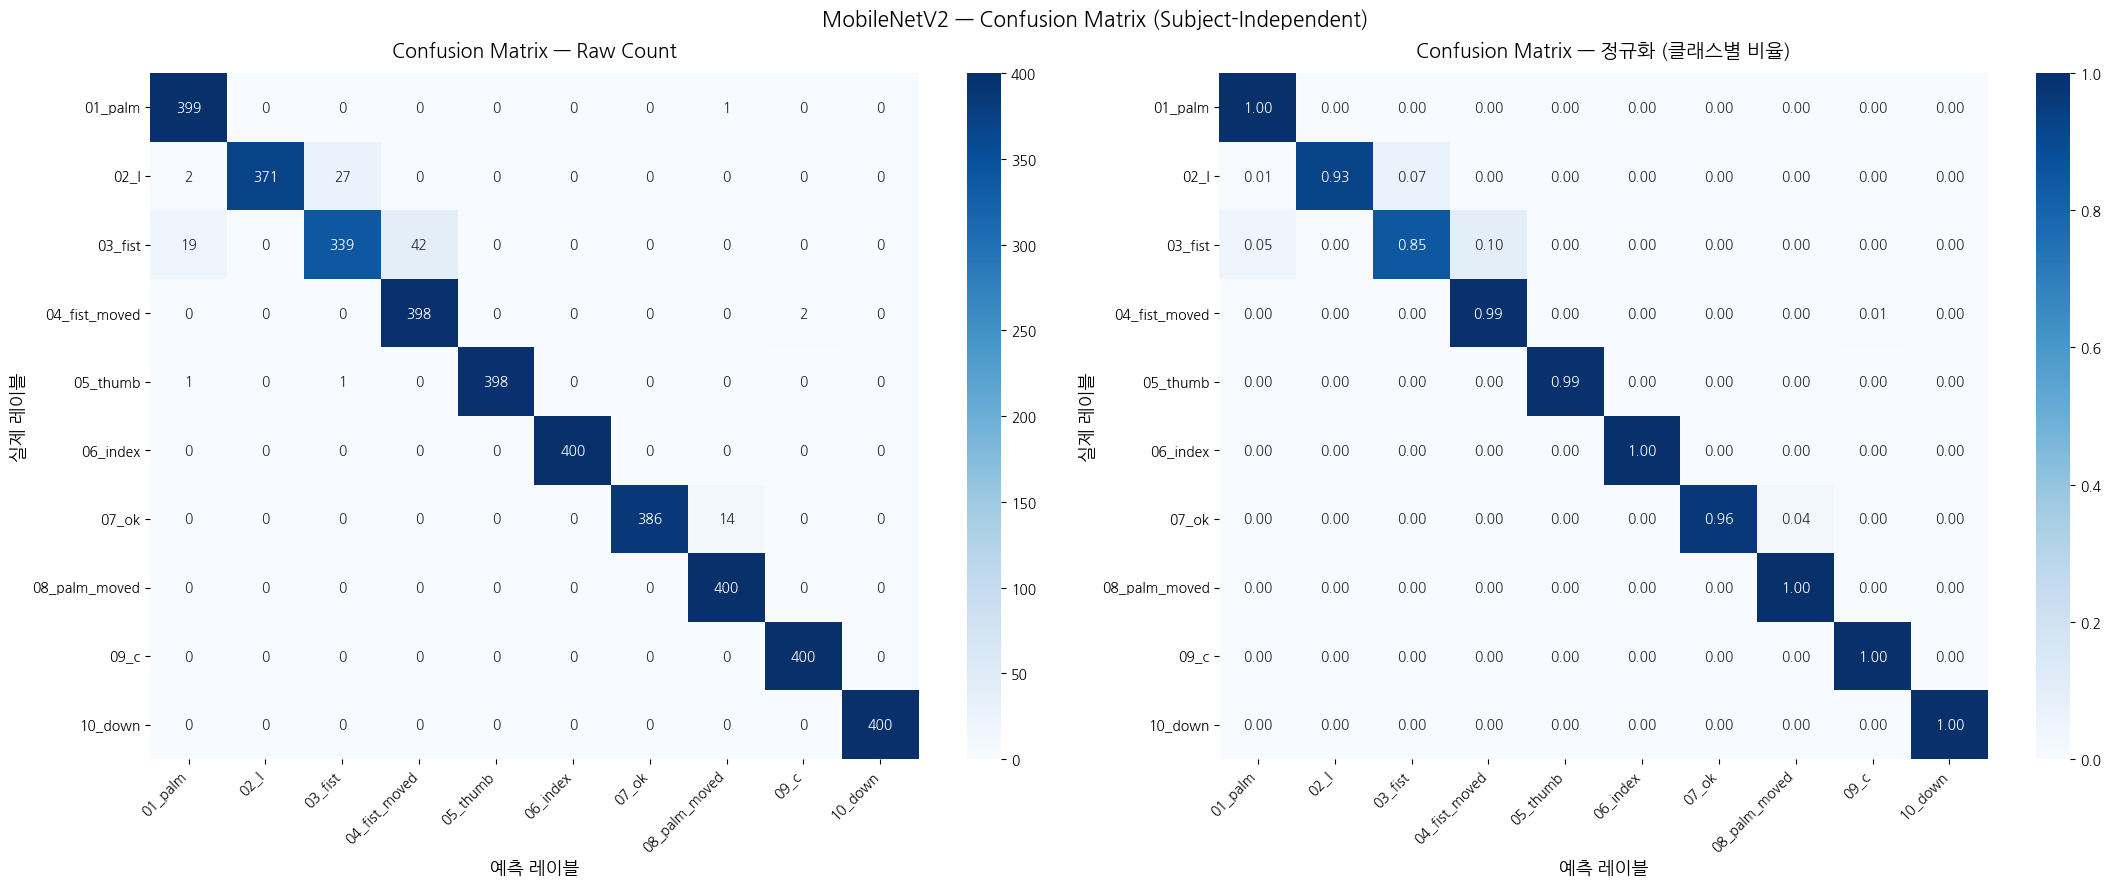

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = train_dataset.classes

print('=== 테스트셋 최종 평가 (피험자 08, 09) ===')
print(classification_report(all_labels, all_preds, target_names=class_names))

# ── Raw Count Confusion Matrix ───────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')  # ✅ 정규화 버전 추가

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('예측 레이블', fontsize=13, fontweight='bold')
axes[0].set_ylabel('실제 레이블', fontsize=13, fontweight='bold')
axes[0].set_title('Confusion Matrix — Raw Count', fontsize=14, pad=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# ── 정규화 Confusion Matrix ──────────────────────────────────
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_xlabel('예측 레이블', fontsize=13, fontweight='bold')
axes[1].set_ylabel('실제 레이블', fontsize=13, fontweight='bold')
axes[1].set_title('Confusion Matrix — 정규화 (클래스별 비율)', fontsize=14, pad=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('MobileNetV2 — Confusion Matrix (Subject-Independent)', fontsize=15)
plt.tight_layout()
plt.show()

예측 샘플 시각화

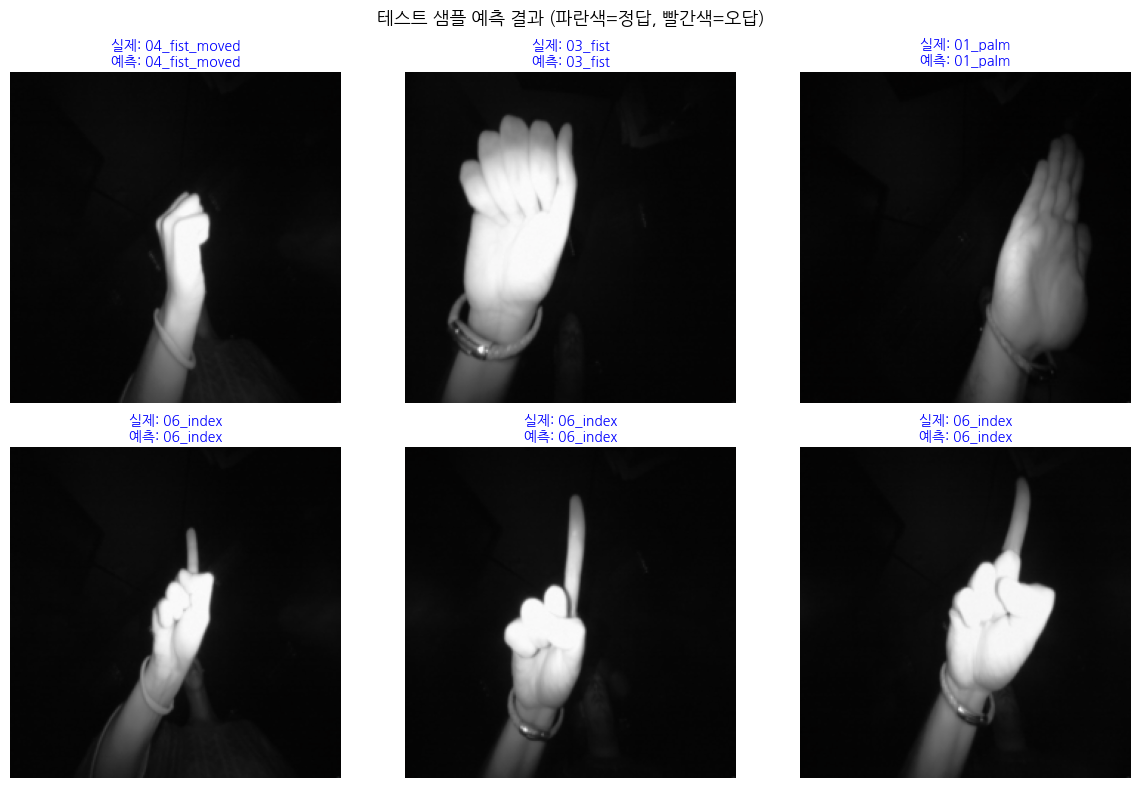

In [15]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

model.eval()
class_names = train_dataset.classes

# ✅ 수정: 샘플 선택 전 시드 고정 → 항상 동일한 6개 샘플
random.seed(SEED)
indices = random.sample(range(len(test_dataset)), 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

inv_mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
inv_std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

with torch.no_grad():
    for i, idx in enumerate(indices):
        image, label = test_dataset[idx]
        img_input = image.unsqueeze(0).to(device)
        output    = model(img_input)
        _, predicted = torch.max(output, 1)

        img_display = (image * inv_std + inv_mean).permute(1, 2, 0).numpy()
        img_display = np.clip(img_display, 0, 1)

        true_label = class_names[label]
        pred_label = class_names[predicted.item()]
        color = 'blue' if true_label == pred_label else 'red'

        axes[i].imshow(img_display)
        axes[i].set_title(f'실제: {true_label}\n예측: {pred_label}', color=color, fontsize=10)
        axes[i].axis('off')

plt.suptitle('테스트 샘플 예측 결과 (파란색=정답, 빨간색=오답)', fontsize=13)
plt.tight_layout()
plt.show()

Gradio 데모

In [ ]:
import gradio as gr
from PIL import Image as PILImage
import random
import numpy as np
import torch

# 1. 예측 함수 (내부 로직용)
def predict_gesture(input_image):
    if input_image is None:
        return {}

    # EfficientNet-B3 규격인 300x300 전처리 적용
    img_tensor = eval_transform(input_image.convert('RGB'))
    img_tensor = img_tensor.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()

    return {train_dataset.classes[i]: float(probs[i]) for i in range(len(train_dataset.classes))}

# 2. 랜덤 샘플 추출 및 시각화용 변환 함수
def get_random_test_sample():
    # 테스트 데이터셋(피험자 08, 09)에서 랜덤 인덱스 추출
    idx = random.randint(0, len(test_dataset) - 1)
    image_tensor, label = test_dataset[idx]

    # 정규화된 텐서를 다시 이미지(0~255)로 역변환
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)

    img_display = image_tensor.permute(1, 2, 0).numpy()
    img_display = (img_display * std) + mean
    img_display = np.clip(img_display, 0, 1)
    img_display = (img_display * 255).astype(np.uint8)

    true_label = train_dataset.classes[label]
    return PILImage.fromarray(img_display), true_label

# 3. 버튼 클릭 시 실행될 메인 함수
def predict_random_sample():
    # 랜덤 이미지와 실제 정답 가져오기
    sample_img, true_label = get_random_test_sample()

    # 모델 예측 실행
    pred_result = predict_gesture(sample_img)

    # 예측 결과 중 가장 높은 확률의 라벨 찾기
    pred_label = max(pred_result, key=pred_result.get)
    correct_text = '✅ 정답' if pred_label == true_label else '❌ 오답'

    info_text = f'실제 라벨: {true_label}\n예측 라벨: {pred_label}\n판정: {correct_text}'
    return sample_img, pred_result, info_text

# 4. Gradio UI 구성 (랜덤 테스트 전용)
gesture_list = ', '.join(train_dataset.classes)
desc_text = f"테스트 데이터셋(피험자 08, 09)에서 무작위 이미지를 불러와 모델의 성능을 검증합니다.\n인식 가능 제스처: {gesture_list}"

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown('# 🖐️ 손 제스처 인식 랜덤 테스트 (EfficientNet-B3)')
    gr.Markdown(desc_text)

    with gr.Column():
        random_image = gr.Image(label='랜덤 테스트 이미지 (Subject 08, 09)', type='pil')
        random_output = gr.Label(num_top_classes=3, label='모델 예측 결과 (상위 3개)')
        random_info = gr.Textbox(label='결과 분석', lines=3)
        random_btn = gr.Button('🎲 랜덤 이미지 불러와서 예측하기', variant='primary')

        # 버튼 클릭 시 이미지, 예측 차트, 텍스트 정보를 동시에 업데이트
        random_btn.click(
            fn=predict_random_sample,
            inputs=None,
            outputs=[random_image, random_output, random_info]
        )

# 데모 실행
demo.launch(share=True, debug=True)

/tmp/ipykernel_21424/503998296.py:60: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b791eaf22f87951432.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
